# Week 3 Portfolio Project: Logistic Regression Classifier from Scratch

This project builds a binary classifier using **logistic regression**, implemented
manually with NumPy — no scikit-learn. It covers everything from Week 3 of
Andrew Ng's Machine Learning Specialization:

- Sigmoid function & model representation
- Decision boundaries
- Logistic loss (cost function)
- Gradient descent for logistic regression
- Overfitting with polynomial features
- L2 regularization

**Author:** Bhavya
**Course:** Machine Learning Specialization — Course 1, Week 3

## Step 1: Setup and Synthetic Dataset

We'll generate our own 2-feature binary classification dataset instead of
downloading one. This gives us full control so we can clearly see how the
decision boundary, cost, and overfitting behave — a real-world CSV would add
noise that obscures the concepts we're trying to learn.

- **Feature 1**: e.g. hours studied
- **Feature 2**: e.g. practice test score
- **Label (y)**: 0 = fail, 1 = pass

We deliberately make the two classes overlap slightly, so the classifier has
a genuinely hard decision to make — not a trivial one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Two features, e.g. "hours studied" and "practice test score"
# Class 0: did not pass, Class 1: passed
m = 100  # number of examples

# Generate two overlapping "blobs" of points
class0 = np.random.randn(m // 2, 2) * 1.2 + np.array([2, 2])
class1 = np.random.randn(m // 2, 2) * 1.2 + np.array([6, 6])

X = np.vstack([class0, class1])
y = np.hstack([np.zeros(m // 2), np.ones(m // 2)])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


## Step 2: Visualize the Raw Data

Before building any model, always look at the data. We're checking that:
- The two classes are visually separable, but not perfectly — there should
  be some overlap.
- The scale of the two features is roughly similar (so gradient descent
  behaves reasonably without needing feature scaling yet).

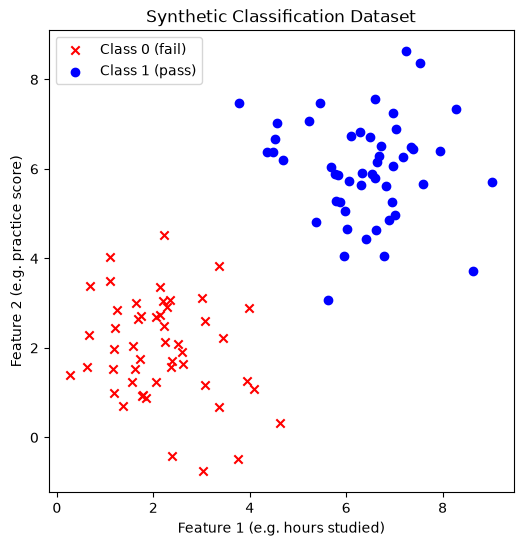

In [2]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='x', label='Class 0 (fail)')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='o', label='Class 1 (pass)')
plt.xlabel('Feature 1 (e.g. hours studied)')
plt.ylabel('Feature 2 (e.g. practice score)')
plt.legend()
plt.title('Synthetic Classification Dataset')
plt.show()

## Step 3: The Sigmoid Function & Model Representation

In Week 1 (linear regression), our model was:

    f(x) = w·x + b

This outputs any real number — great for predicting continuous values like
salary, but useless for classification, where we want an output between 0
and 1 that we can interpret as a **probability**.

Logistic regression fixes this by passing the linear output through the
**sigmoid function**:

    g(z) = 1 / (1 + e^(-z))

Then the model becomes:

    z = w·x + b
    f(x) = g(z) = 1 / (1 + e^(-(w·x + b)))

**Why sigmoid specifically?**
- As z → +∞, g(z) → 1
- As z → -∞, g(z) → 0
- At z = 0, g(z) = 0.5

So it smoothly "squashes" any real number into the (0, 1) range, which we can
interpret as: *"the model's estimated probability that y = 1, given x."*

We typically **predict class 1 if f(x) ≥ 0.5, and class 0 otherwise** — which,
looking at the sigmoid's shape, is exactly the same as predicting 1 whenever
z ≥ 0.

In [3]:
def sigmoid(z):
    """
    Compute the sigmoid of z, element-wise.

    Args:
        z (ndarray or scalar): input value(s)

    Returns:
        g (ndarray or scalar): sigmoid(z), same shape as z
    """
    return 1 / (1 + np.exp(-z))

## Step 4: Sanity-Check the Sigmoid Function

Before using sigmoid inside a model, let's verify it behaves the way the math
says it should:

- `sigmoid(0)` should be exactly `0.5`
- `sigmoid` of a large positive number should be close to `1`
- `sigmoid` of a large negative number should be close to `0`
- Plotting it should show the characteristic "S-curve"

sigmoid(0)   = 0.5
sigmoid(10)  = 0.9999546021312976
sigmoid(-10) = 4.5397868702434395e-05


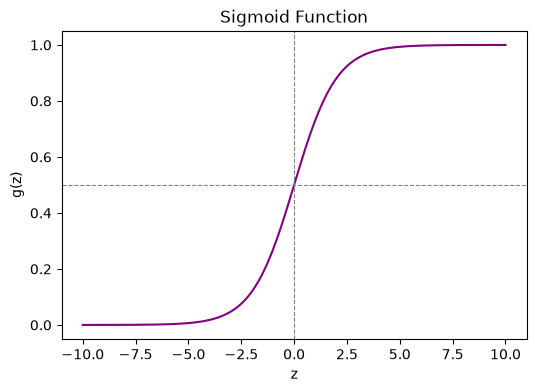

In [6]:
# Quick numeric checks
print("sigmoid(0)   =", sigmoid(0))
print("sigmoid(10)  =", sigmoid(10))
print("sigmoid(-10) =", sigmoid(-10))

# Visualize the S-curve
z_vals = np.linspace(-10, 10, 200)
g_vals = sigmoid(z_vals)

plt.figure(figsize=(6, 4))
plt.plot(z_vals, g_vals, c='purple')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('z')
plt.ylabel('g(z)')
plt.title('Sigmoid Function')
plt.show()

## Step 5: Model Representation Function

Now we combine the linear part (`w·x + b`) with sigmoid into a single
function representing our logistic regression model. This is the function
we'll use to make predictions once `w` and `b` are learned (and also during
training, to compute the cost and gradients).

- `X`: shape (m, n) — m examples, n features
- `w`: shape (n,) — one weight per feature
- `b`: scalar — bias term

`X @ w` computes the dot product `w·x` for every example at once (vectorized,
instead of looping over examples — much faster and cleaner in NumPy).

In [7]:
def predict_proba(X, w, b):
    """
    Compute the logistic regression model's predicted probabilities.

    Args:
        X (ndarray): shape (m, n), input features
        w (ndarray): shape (n,), model weights
        b (scalar):  model bias

    Returns:
        ndarray: shape (m,), predicted probability that y=1 for each example
    """
    z = X @ w + b
    return sigmoid(z)

In [8]:
# Quick test with random initial weights (untrained model — just checking shapes work)
w_init = np.zeros(X.shape[1])
b_init = 0.0

probs = predict_proba(X, w_init, b_init)
print("First 5 predicted probabilities:", probs[:5])
print("Shape:", probs.shape)

First 5 predicted probabilities: [0.5 0.5 0.5 0.5 0.5]
Shape: (100,)


## Step 6: Understanding the Decision Boundary

The **decision boundary** is the line (in 2D) where the model is exactly
undecided — where predicted probability = 0.5.

Since predict_proba(x) = 0.5 exactly when z = w·x + b = 0, the decision
boundary is simply the line:

    w1*x1 + w2*x2 + b = 0

Rearranged to plot as x2 vs x1:

    x2 = -(w1*x1 + b) / w2

Everywhere on one side of this line, z > 0 → predicted probability > 0.5 →
predicted class 1. On the other side, z < 0 → predicted class 0.

Right now, our weights are `w = [0, 0]` and `b = 0`. Let's see what boundary
that produces — and why it's meaningless until we train the model.

In [10]:
def plot_decision_boundary(X, y, w, b, title="Decision Boundary"):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='x', label='Class 0 (fail)')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='o', label='Class 1 (pass)')

    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

    if w[1] != 0:
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        plt.plot(x1_vals, x2_vals, c='green', label='Decision boundary')
    else:
        print("w2 is 0 — boundary is vertical or undefined for this plot form.")

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title(title)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.show()

w_init: [0. 0.]  b_init: 0.0


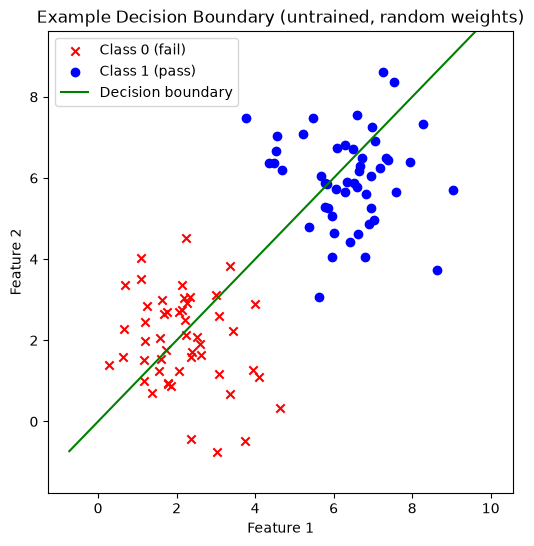

In [11]:
# Untrained model: w = [0, 0], b = 0 — this can't define a real boundary line yet
print("w_init:", w_init, " b_init:", b_init)

# Let's instead pick a deliberately bad/random line just to see the mechanic work
w_demo = np.array([1.0, -1.0])
b_demo = 0.0

plot_decision_boundary(X, y, w_demo, b_demo, title="Example Decision Boundary (untrained, random weights)")

## Step 7: Why Not Use Squared Error Here?

In Week 1, we used the **squared error cost function** for linear regression.
For logistic regression, squared error turns out to be a bad choice: because
of the sigmoid's nonlinearity, plugging squared error into logistic
regression produces a **non-convex** cost surface — one with lots of local
minima — so gradient descent could get stuck instead of finding the best fit.

Instead, we use the **logistic loss** (also called log loss), defined
per-example as:

    loss(f, y) = -y * log(f) - (1 - y) * log(1 - f)

where `f` is the predicted probability (from sigmoid) and `y` is the true
label (0 or 1). Let's unpack why this makes sense:

- If **y = 1**: loss = -log(f).
  - If f is close to 1 (correct, confident) → loss ≈ 0.
  - If f is close to 0 (confidently wrong) → loss → ∞ (huge penalty).
- If **y = 0**: loss = -log(1 - f).
  - If f is close to 0 (correct, confident) → loss ≈ 0.
  - If f is close to 1 (confidently wrong) → loss → ∞.

So this loss **heavily punishes confident wrong predictions**, and rewards
confident correct

In [12]:
def compute_cost(X, y, w, b):
    """
    Compute the logistic regression cost function J(w, b).

    Args:
        X (ndarray): shape (m, n), input features
        y (ndarray): shape (m,), true labels (0 or 1)
        w (ndarray): shape (n,), model weights
        b (scalar):  model bias

    Returns:
        cost (scalar): the average logistic loss over all examples
    """
    m = X.shape[0]
    f = predict_proba(X, w, b)

    # Small epsilon to avoid log(0), which is undefined
    eps = 1e-15
    f = np.clip(f, eps, 1 - eps)

    cost = -np.mean(y * np.log(f) + (1 - y) * np.log(1 - f))
    return cost

## Step 8: Sanity-Check the Cost Function

Two quick checks:
1. With our untrained model (`w = [0, 0], b = 0`), every prediction is 0.5.
   The cost should be `-log(0.5) ≈ 0.693` — this is a useful "baseline"
   number: any trained model should end up with a lower cost than this.
2. The cost should decrease if we plug in weights that separate the classes
   better (like ones roughly pointing from the red blob toward the blue
   blob).

In [14]:
# Baseline cost with untrained model
cost_init = compute_cost(X, y, w_init, b_init)
print("Cost with w=0, b=0:", cost_init)
print("Expected ~0.693 (i.e. -log(0.5))")

# Cost with a "reasonable-looking" guess (pointing from class0 center toward class1 center)
w_guess = np.array([1.0, 1.0])
b_guess = -8.0
cost_guess = compute_cost(X, y, w_guess, b_guess)
print("Cost with a reasonable guess:", cost_guess)

Cost with w=0, b=0: 0.6931471805599453
Expected ~0.693 (i.e. -log(0.5))
Cost with a reasonable guess: 0.03901077767217819


## Step 9: Gradient Descent for Logistic Regression

Just like in Week 1, we improve `w` and `b` by repeatedly stepping in the
direction that reduces the cost `J(w, b)`. The update rules look almost
identical to linear regression:

    w_j := w_j - α * (∂J/∂w_j)
    b   := b   - α * (∂J/∂b)

where α (alpha) is the learning rate. The partial derivatives turn out to be:

    ∂J/∂w_j = (1/m) * Σ (f_i - y_i) * x_i_j
    ∂J/∂b   = (1/m) * Σ (f_i - y_i)

This looks **exactly like linear regression's gradient formulas** — the only
difference is that `f_i` here comes from the sigmoid, not from a plain linear
function. That's not a coincidence: it's a direct result of pairing the
logistic loss with the sigmoid function, which makes the math work out
cleanly.

**Important**: all `w_j` and `b` must be updated **simultaneously** — using
the gradients computed from the *old* `w, b`, not values already partially
updated. Vectorizing with NumPy naturally gives us this for free, since we
compute all gradients before applying any updates.

In [15]:
def compute_gradient(X, y, w, b):
    """
    Compute the gradient of the cost function w.r.t. w and b.

    Args:
        X (ndarray): shape (m, n), input features
        y (ndarray): shape (m,), true labels (0 or 1)
        w (ndarray): shape (n,), model weights
        b (scalar):  model bias

    Returns:
        dj_dw (ndarray): shape (n,), gradient w.r.t. w
        dj_db (scalar):  gradient w.r.t. b
    """
    m = X.shape[0]
    f = predict_proba(X, w, b)
    error = f - y  # shape (m,)

    dj_dw = (1 / m) * (X.T @ error)  # shape (n,)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

## Step 10: The Gradient Descent Loop

This function repeatedly:
1. Computes the gradient at the current `w, b`
2. Updates `w, b` using the learning rate `α`
3. Records the cost every so often, so we can plot how it decreases over
   iterations (this plot is one of the best debugging tools in ML — if cost
   isn't decreasing, something's wrong with your learning rate or your
   gradient math)

In [16]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    """
    Perform batch gradient descent to learn w, b.

    Args:
        X (ndarray): shape (m, n), input features
        y (ndarray): shape (m,), true labels
        w_in (ndarray): initial weights
        b_in (scalar):  initial bias
        alpha (float):  learning rate
        num_iters (int): number of iterations to run

    Returns:
        w (ndarray): learned weights
        b (scalar):  learned bias
        cost_history (list): cost at each recorded iteration
    """
    w = w_in.copy()
    b = b_in
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0 or i == num_iters - 1:
            cost = compute_cost(X, y, w, b)
            cost_history.append(cost)
            print(f"Iteration {i:4}: Cost = {cost:.4f}")

    return w, b, cost_history

In [19]:
# Run gradient descent from scratch (w=0, b=0)
w_final, b_final, cost_history = gradient_descent(
    X, y,
    w_in=np.zeros(X.shape[1]),
    b_in=0.0,
    alpha=0.1,
    num_iters=1000
)

print("\nLearned w:", w_final)
print("Learned b:", b_final)

Iteration    0: Cost = 0.5901
Iteration  100: Cost = 0.3399
Iteration  200: Cost = 0.2337
Iteration  300: Cost = 0.1786
Iteration  400: Cost = 0.1454
Iteration  500: Cost = 0.1233
Iteration  600: Cost = 0.1075
Iteration  700: Cost = 0.0956
Iteration  800: Cost = 0.0864
Iteration  900: Cost = 0.0790
Iteration  999: Cost = 0.0729

Learned w: [0.84626908 0.67902211]
Learned b: -5.866990190795999


## Step 11: Visualize the Trained Decision Boundary and Cost Curve

Now that we have learned `w` and `b`, let's check two things visually:

1. **Decision boundary** — does the green line now actually separate the red
   and blue points reasonably well (using the same `plot_decision_boundary`
   function from Step 6)?
2. **Cost curve** — does cost vs. iteration show the classic smooth,
   monotonically decreasing curve that flattens out? A curve that's still
   dropping steeply at the end suggests more iterations would help; a flat
   curve from early on suggests iterations are being "wasted."

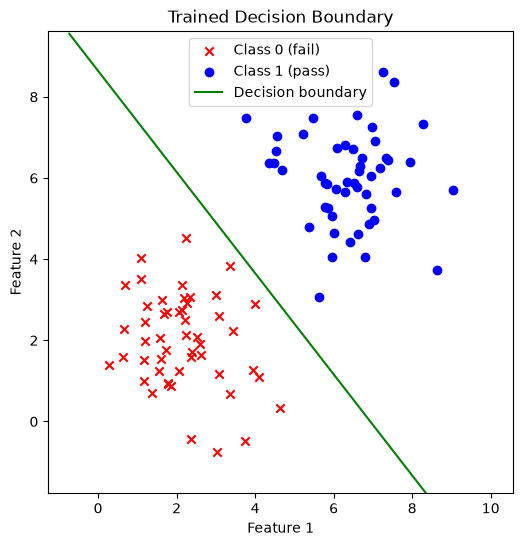

In [20]:
plot_decision_boundary(X, y, w_final, b_final, title="Trained Decision Boundary")

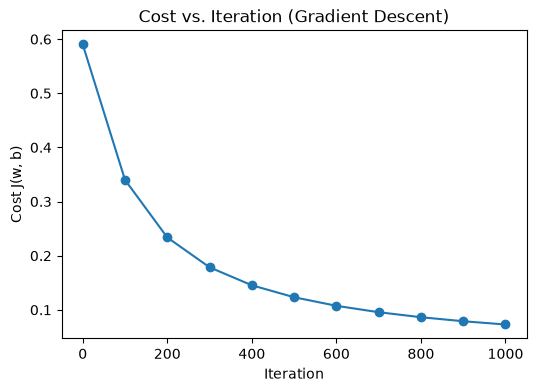

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(range(0, len(cost_history) * 100, 100), cost_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.title('Cost vs. Iteration (Gradient Descent)')
plt.show()

## Step 12: Measuring Accuracy

Cost tells us how well-calibrated the probabilities are, but a more
intuitive metric for classification is **accuracy** — the fraction of
examples where the predicted class matches the true label.

Recall: predicted class = 1 if predicted probability ≥ 0.5, else 0. This is
the same threshold that defines the decision boundary itself.

In [22]:
def predict_class(X, w, b, threshold=0.5):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

y_pred = predict_class(X, w_final, b_final)
accuracy = np.mean(y_pred == y) * 100
print(f"Training accuracy: {accuracy:.2f}%")

Training accuracy: 100.00%


## Step 13: The Problem of Overfitting

Our current model is a simple **linear** decision boundary — one straight
line. With only 2 features, that's low capacity: it can't wiggle around to
chase individual noisy points, which is why it generalizes well.

But what if we make the model **more flexible** by feeding it engineered
polynomial features (x1², x2², x1*x2, x1³, etc.) instead of just x1 and x2?
The model is still "logistic regression" — still just a linear combination
of features passed through sigmoid — but because the *features themselves*
are now nonlinear functions of x1, x2, the resulting decision boundary in
the original x1-x2 space can become a complex curve.

With enough polynomial degree, the model has enough freedom to bend around
and closely fit even the noisy/overlapping points in our training set — this
is **overfitting**: great training accuracy, but a boundary so squiggly it
would likely generalize poorly to new data.

We'll build a `map_polynomial_features` function to generate these extra
features, then train the same logistic regression on top of them.

In [23]:
def map_polynomial_features(X, degree):
    """
    Generate polynomial features up to the given degree from 2 input features.

    E.g. for degree=2, transforms [x1, x2] into:
        [x1, x2, x1^2, x1*x2, x2^2]

    Args:
        X (ndarray): shape (m, 2), original 2 features
        degree (int): max polynomial degree

    Returns:
        ndarray: shape (m, num_new_features), expanded feature set
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    features = []

    for total_degree in range(1, degree + 1):
        for i in range(total_degree + 1):
            # i is the power of x1, (total_degree - i) is the power of x2
            features.append((x1 ** (total_degree - i)) * (x2 ** i))

    return np.column_stack(features)

In [24]:
# Quick check: degree 1 should just give us back x1, x2 (2 features)
# degree 2 should give us 5 features: x1, x2, x1^2, x1*x2, x2^2
X_deg1 = map_polynomial_features(X, degree=1)
X_deg2 = map_polynomial_features(X, degree=2)

print("Degree 1 shape:", X_deg1.shape)
print("Degree 2 shape:", X_deg2.shape)

Degree 1 shape: (100, 2)
Degree 2 shape: (100, 5)


## Step 14: Feature Scaling for Polynomial Features

Before training on polynomial features, there's a practical problem: x1³ or
x1⁴ can be **much larger in magnitude** than x1 itself. If some features are
in the range of hundreds while others are near 1, gradient descent struggles
— it ends up needing a tiny learning rate to avoid diverging on the
large-scale features, which makes learning painfully slow on the small-scale
ones.

The fix is **z-score normalization**, applied per feature:

    x_scaled = (x - mean(x)) / std(x)

This isn't a new Week 3 concept by name, but it's a necessary practical step
to make polynomial features trainable — without it, gradient descent likely
won't converge no matter how carefully we pick alpha.

In [25]:
def zscore_normalize(X):
    """
    Normalize each feature (column) of X to zero mean, unit variance.

    Args:
        X (ndarray): shape (m, n)

    Returns:
        X_norm (ndarray): normalized features, same shape
        mu (ndarray): shape (n,), mean of each feature (needed to normalize new data later)
        sigma (ndarray): shape (n,), std of each feature
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

## Step 15: Train an Overfit Model (Degree 6 Polynomial)

Now let's:
1. Expand our 2 features into degree-6 polynomial features
2. Normalize them
3. Run the *exact same* `gradient_descent` function we already built — no
   changes needed, since it only cares about `X` and `y` shapes, not what
   the features mean

In [26]:
degree = 6
X_poly = map_polynomial_features(X, degree=degree)
X_poly_norm, mu_poly, sigma_poly = zscore_normalize(X_poly)

print("X_poly shape:", X_poly.shape)  # should be (100, 27) for degree 6

w_overfit, b_overfit, cost_history_overfit = gradient_descent(
    X_poly_norm, y,
    w_in=np.zeros(X_poly_norm.shape[1]),
    b_in=0.0,
    alpha=0.5,
    num_iters=3000
)

X_poly shape: (100, 27)
Iteration    0: Cost = 0.1138
Iteration  100: Cost = 0.0177
Iteration  200: Cost = 0.0105
Iteration  300: Cost = 0.0076
Iteration  400: Cost = 0.0061
Iteration  500: Cost = 0.0050
Iteration  600: Cost = 0.0043
Iteration  700: Cost = 0.0038
Iteration  800: Cost = 0.0034
Iteration  900: Cost = 0.0031
Iteration 1000: Cost = 0.0028
Iteration 1100: Cost = 0.0026
Iteration 1200: Cost = 0.0024
Iteration 1300: Cost = 0.0023
Iteration 1400: Cost = 0.0021
Iteration 1500: Cost = 0.0020
Iteration 1600: Cost = 0.0019
Iteration 1700: Cost = 0.0018
Iteration 1800: Cost = 0.0017
Iteration 1900: Cost = 0.0016
Iteration 2000: Cost = 0.0016
Iteration 2100: Cost = 0.0015
Iteration 2200: Cost = 0.0014
Iteration 2300: Cost = 0.0014
Iteration 2400: Cost = 0.0013
Iteration 2500: Cost = 0.0013
Iteration 2600: Cost = 0.0012
Iteration 2700: Cost = 0.0012
Iteration 2800: Cost = 0.0012
Iteration 2900: Cost = 0.0011
Iteration 2999: Cost = 0.0011


## Step 16: Plotting a Nonlinear Decision Boundary

Our earlier `plot_decision_boundary` function assumed a straight line, which
only works when we have exactly 2 raw features (w1*x1 + w2*x2 + b = 0). Now
that the boundary can curve, we need a more general approach:

1. Create a fine grid of (x1, x2) points covering the plot area
2. Map each grid point through the same polynomial expansion + normalization
3. Predict the probability at every grid point
4. Draw a contour line where predicted probability = 0.5

This grid-and-contour technique is the standard way to visualize nonlinear
decision boundaries, and it'll work no matter how curvy the boundary gets.

In [27]:
def plot_nonlinear_boundary(X, y, w, b, degree, mu, sigma, title="Decision Boundary"):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='x', label='Class 0 (fail)')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='o', label='Class 1 (pass)')

    x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)

    grid_points = np.column_stack([xx1.ravel(), xx2.ravel()])
    grid_poly = map_polynomial_features(grid_points, degree=degree)
    grid_poly_norm = (grid_poly - mu) / sigma

    probs = predict_proba(grid_poly_norm, w, b)
    probs = probs.reshape(xx1.shape)

    plt.contour(xx1, xx2, probs, levels=[0.5], colors='green')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title(title)
    plt.show()

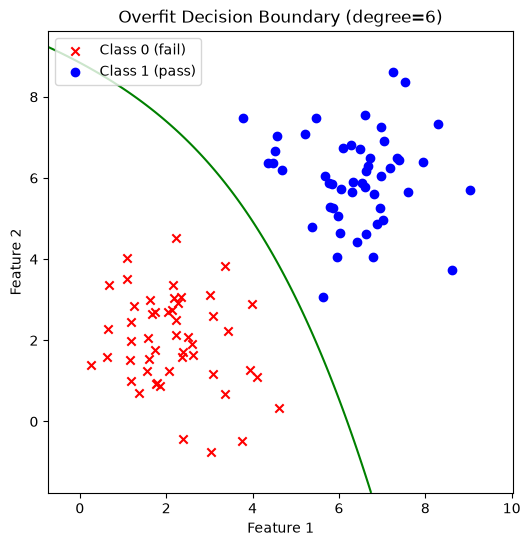

Training accuracy (overfit model): 100.00%


In [28]:
plot_nonlinear_boundary(X, y, w_overfit, b_overfit, degree, mu_poly, sigma_poly,
                          title=f"Overfit Decision Boundary (degree={degree})")

y_pred_overfit = predict_class(X_poly_norm, w_overfit, b_overfit)
accuracy_overfit = np.mean(y_pred_overfit == y) * 100
print(f"Training accuracy (overfit model): {accuracy_overfit:.2f}%")

## Step 17: Adding Noise to Make Overfitting Visible

Our current data is too cleanly separable — a straight line already gets
100% accuracy, so a flexible polynomial model has no "hard" points to chase.

To actually see overfitting, we need a few **mislabeled or noisy points** —
points that sit on the wrong side of the "true" boundary. A high-degree
polynomial model, given enough flexibility, will bend the boundary into odd
little pockets just to correctly classify these noisy points. A simple
linear model can't do this — it will just accept a few mistakes and keep a
smooth, general boundary.

This is precisely why overfitting is dangerous: chasing 100% training
accuracy on noisy data produces a model that has memorized noise rather than
learned the true underlying pattern.

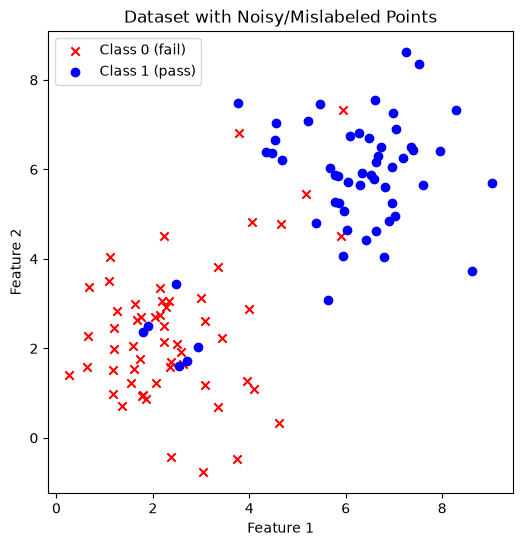

In [29]:
# Add a handful of "noisy" points that cross into the opposite class's territory
np.random.seed(2)
noise_class0 = np.random.randn(6, 2) * 0.8 + np.array([5.5, 5.5])  # red points inside blue territory
noise_class1 = np.random.randn(6, 2) * 0.8 + np.array([2.5, 2.5])  # blue points inside red territory

X_noisy = np.vstack([X, noise_class0, noise_class1])
y_noisy = np.hstack([y, np.zeros(6), np.ones(6)])

plt.figure(figsize=(6, 6))
plt.scatter(X_noisy[y_noisy == 0, 0], X_noisy[y_noisy == 0, 1], c='red', marker='x', label='Class 0 (fail)')
plt.scatter(X_noisy[y_noisy == 1, 0], X_noisy[y_noisy == 1, 1], c='blue', marker='o', label='Class 1 (pass)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Dataset with Noisy/Mislabeled Points')
plt.show()

## Step 18: Retrain Linear vs. Degree-6 Model on Noisy Data

Now we'll train two models on the same noisy dataset:

1. **Linear model** (degree 1, i.e. just raw x1, x2) — limited capacity, so
   it can't chase every noisy point. Expect it to accept a few
   misclassifications and keep a smooth, sensible boundary.
2. **Degree-6 polynomial model** — high capacity. Expect it to bend the
   boundary into odd pockets around the noisy points to keep training
   accuracy high.

This side-by-side comparison is the clearest possible illustration of
overfitting: same data, same algorithm, only the model's *flexibility*
differs.

Iteration    0: Cost = 0.6241
Iteration  100: Cost = 0.4528
Iteration  200: Cost = 0.3826
Iteration  300: Cost = 0.3491
Iteration  400: Cost = 0.3311
Iteration  500: Cost = 0.3206
Iteration  600: Cost = 0.3140
Iteration  700: Cost = 0.3097
Iteration  800: Cost = 0.3068
Iteration  900: Cost = 0.3048
Iteration  999: Cost = 0.3034

Linear model training accuracy on noisy data: 89.29%


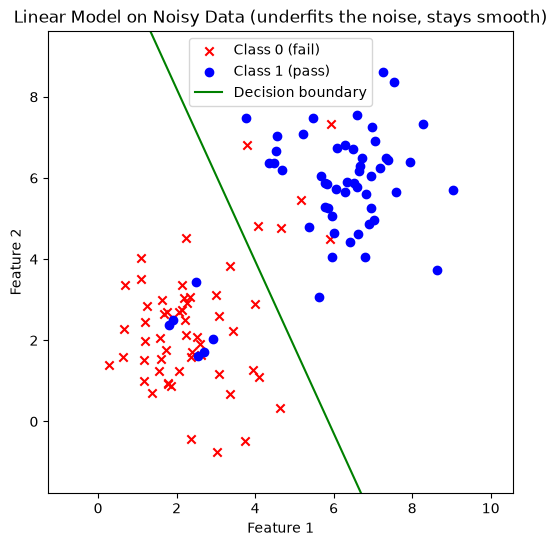

In [30]:
# --- Linear model (degree 1) on noisy data ---
w_linear_noisy, b_linear_noisy, cost_hist_linear = gradient_descent(
    X_noisy, y_noisy,
    w_in=np.zeros(X_noisy.shape[1]),
    b_in=0.0,
    alpha=0.1,
    num_iters=1000
)

y_pred_linear_noisy = predict_class(X_noisy, w_linear_noisy, b_linear_noisy)
acc_linear_noisy = np.mean(y_pred_linear_noisy == y_noisy) * 100
print(f"\nLinear model training accuracy on noisy data: {acc_linear_noisy:.2f}%")

plot_decision_boundary(X_noisy, y_noisy, w_linear_noisy, b_linear_noisy,
                        title="Linear Model on Noisy Data (underfits the noise, stays smooth)")

Iteration    0: Cost = 0.3420
Iteration  100: Cost = 0.2899
Iteration  200: Cost = 0.2885
Iteration  300: Cost = 0.2875
Iteration  400: Cost = 0.2867
Iteration  500: Cost = 0.2860
Iteration  600: Cost = 0.2854
Iteration  700: Cost = 0.2849
Iteration  800: Cost = 0.2845
Iteration  900: Cost = 0.2840
Iteration 1000: Cost = 0.2837
Iteration 1100: Cost = 0.2833
Iteration 1200: Cost = 0.2829
Iteration 1300: Cost = 0.2826
Iteration 1400: Cost = 0.2823
Iteration 1500: Cost = 0.2820
Iteration 1600: Cost = 0.2817
Iteration 1700: Cost = 0.2814
Iteration 1800: Cost = 0.2811
Iteration 1900: Cost = 0.2809
Iteration 2000: Cost = 0.2806
Iteration 2100: Cost = 0.2804
Iteration 2200: Cost = 0.2801
Iteration 2300: Cost = 0.2799
Iteration 2400: Cost = 0.2796
Iteration 2500: Cost = 0.2794
Iteration 2600: Cost = 0.2792
Iteration 2700: Cost = 0.2789
Iteration 2800: Cost = 0.2787
Iteration 2900: Cost = 0.2785
Iteration 2999: Cost = 0.2783

Degree-6 model training accuracy on noisy data: 90.18%


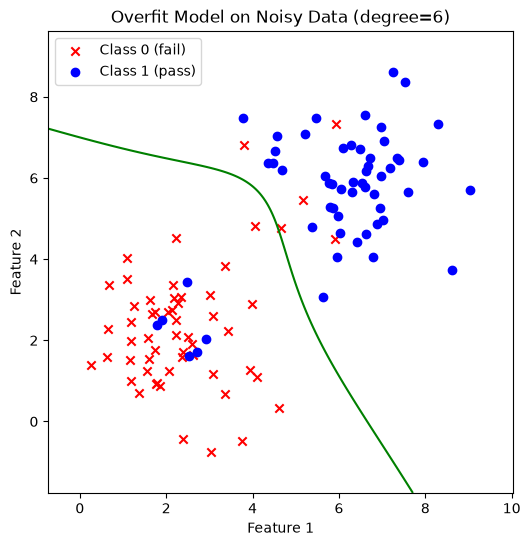

In [31]:
# --- Degree-6 polynomial model on noisy data ---
degree = 6
X_poly_noisy = map_polynomial_features(X_noisy, degree=degree)
X_poly_noisy_norm, mu_poly_noisy, sigma_poly_noisy = zscore_normalize(X_poly_noisy)

w_overfit_noisy, b_overfit_noisy, cost_hist_overfit_noisy = gradient_descent(
    X_poly_noisy_norm, y_noisy,
    w_in=np.zeros(X_poly_noisy_norm.shape[1]),
    b_in=0.0,
    alpha=0.5,
    num_iters=3000
)

y_pred_overfit_noisy = predict_class(X_poly_noisy_norm, w_overfit_noisy, b_overfit_noisy)
acc_overfit_noisy = np.mean(y_pred_overfit_noisy == y_noisy) * 100
print(f"\nDegree-6 model training accuracy on noisy data: {acc_overfit_noisy:.2f}%")

plot_nonlinear_boundary(X_noisy, y_noisy, w_overfit_noisy, b_overfit_noisy, degree,
                          mu_poly_noisy, sigma_poly_noisy,
                          title=f"Overfit Model on Noisy Data (degree={degree})")

## Step 19: L2 Regularization — Penalizing Complexity

Regularization adds a penalty term to the cost function that discourages
large weight values:

    J(w, b) = (1/m) * Σ [ -y_i*log(f_i) - (1-y_i)*log(1-f_i) ]  +  (λ / (2m)) * Σ (w_j)^2

- The first term is our familiar logistic loss (fit the data well).
- The second term is the **regularization term** — it grows whenever any
  weight `w_j` gets large. λ (lambda) controls how much we care about this
  penalty relative to fitting the data.
- Note: **b is not regularized** — only the weights `w_j`. This is standard
  convention; regularizing the bias doesn't help prevent overfitting and can
  actually hurt the fit.

**Why does this fight overfitting?** A wiggly, overfit boundary requires
large-magnitude weights on the higher-degree polynomial terms to create
those sharp bends and pockets. By penalizing large weights, we're directly
discouraging the model from using that complexity — pushing it back toward
a simpler, smoother boundary — unless the data really demands that
complexity to reduce loss.

- **λ = 0**: no regularization (identical to what we've already built)
- **Small λ**: mild smoothing
- **Large λ**: heavy smoothing — if too large, the model may underfit
  (boundary too simple to capture real structure)

This λ is a **hyperparameter we choose**, not something learned by gradient
descent — later, we'll experiment with different values to see this
trade-off directly.

In [32]:
def compute_cost_regularized(X, y, w, b, lambda_):
    """
    Compute the regularized logistic regression cost function.

    Args:
        X (ndarray): shape (m, n)
        y (ndarray): shape (m,)
        w (ndarray): shape (n,)
        b (scalar)
        lambda_ (float): regularization strength

    Returns:
        cost (scalar)
    """
    m = X.shape[0]

    # Same unregularized loss as before
    base_cost = compute_cost(X, y, w, b)

    # Regularization term (note: does NOT include b)
    reg_term = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return base_cost + reg_term

## Step 20: Regularized Gradients

Adding the regularization term to the cost changes the gradient with respect
to each `w_j` (but not `b`, since we don't regularize it):

    ∂J/∂w_j = (1/m) * Σ (f_i - y_i) * x_i_j  +  (λ/m) * w_j
    ∂J/∂b   = (1/m) * Σ (f_i - y_i)          (unchanged)

The extra `(λ/m) * w_j` term is what actively "shrinks" each weight a little
on every update, on top of whatever the data-fit gradient says to do.

In [33]:
def compute_gradient_regularized(X, y, w, b, lambda_):
    """
    Compute the gradient of the regularized cost function.

    Args:
        X, y, w, b: same as before
        lambda_ (float): regularization strength

    Returns:
        dj_dw (ndarray): shape (n,)
        dj_db (scalar)
    """
    m = X.shape[0]

    dj_dw, dj_db = compute_gradient(X, y, w, b)  # reuse unregularized version

    # Add regularization term to dj_dw only (not dj_db)
    dj_dw = dj_dw + (lambda_ / m) * w

    return dj_dw, dj_db

In [34]:
def gradient_descent_regularized(X, y, w_in, b_in, alpha, num_iters, lambda_):
    """
    Batch gradient descent with L2 regularization.
    """
    w = w_in.copy()
    b = b_in
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_regularized(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0 or i == num_iters - 1:
            cost = compute_cost_regularized(X, y, w, b, lambda_)
            cost_history.append(cost)
            print(f"Iteration {i:4}: Cost = {cost:.4f}")

    return w, b, cost_history

## Step 21: Train Regularized Models with Different λ Values

Let's train the same degree-6 polynomial features on the noisy data, but now
using `gradient_descent_regularized` with a few different λ values. We
expect:

- **λ = 0**: identical to our earlier overfit result (kinked boundary,
  chasing noisy points)
- **λ = 1**: mild smoothing — some flexibility retained, less chasing of noise
- **λ = 10**: much smoother, closer to the simple linear boundary
- **λ = 50** (or higher): may start to underfit — boundary too rigid,
  ignoring real structure in the data

We'll plot all of them side by side to see the trend directly.

In [35]:
lambdas_to_try = [0, 1, 10, 50]
results = {}

for lam in lambdas_to_try:
    print(f"\n--- Training with lambda = {lam} ---")
    w_reg, b_reg, cost_hist_reg = gradient_descent_regularized(
        X_poly_noisy_norm, y_noisy,
        w_in=np.zeros(X_poly_noisy_norm.shape[1]),
        b_in=0.0,
        alpha=0.5,
        num_iters=3000,
        lambda_=lam
    )
    y_pred_reg = predict_class(X_poly_noisy_norm, w_reg, b_reg)
    acc_reg = np.mean(y_pred_reg == y_noisy) * 100
    print(f"Training accuracy (lambda={lam}): {acc_reg:.2f}%")

    results[lam] = {"w": w_reg, "b": b_reg, "accuracy": acc_reg}


--- Training with lambda = 0 ---
Iteration    0: Cost = 0.3420
Iteration  100: Cost = 0.2899
Iteration  200: Cost = 0.2885
Iteration  300: Cost = 0.2875
Iteration  400: Cost = 0.2867
Iteration  500: Cost = 0.2860
Iteration  600: Cost = 0.2854
Iteration  700: Cost = 0.2849
Iteration  800: Cost = 0.2845
Iteration  900: Cost = 0.2840
Iteration 1000: Cost = 0.2837
Iteration 1100: Cost = 0.2833
Iteration 1200: Cost = 0.2829
Iteration 1300: Cost = 0.2826
Iteration 1400: Cost = 0.2823
Iteration 1500: Cost = 0.2820
Iteration 1600: Cost = 0.2817
Iteration 1700: Cost = 0.2814
Iteration 1800: Cost = 0.2811
Iteration 1900: Cost = 0.2809
Iteration 2000: Cost = 0.2806
Iteration 2100: Cost = 0.2804
Iteration 2200: Cost = 0.2801
Iteration 2300: Cost = 0.2799
Iteration 2400: Cost = 0.2796
Iteration 2500: Cost = 0.2794
Iteration 2600: Cost = 0.2792
Iteration 2700: Cost = 0.2789
Iteration 2800: Cost = 0.2787
Iteration 2900: Cost = 0.2785
Iteration 2999: Cost = 0.2783
Training accuracy (lambda=0): 90.18%

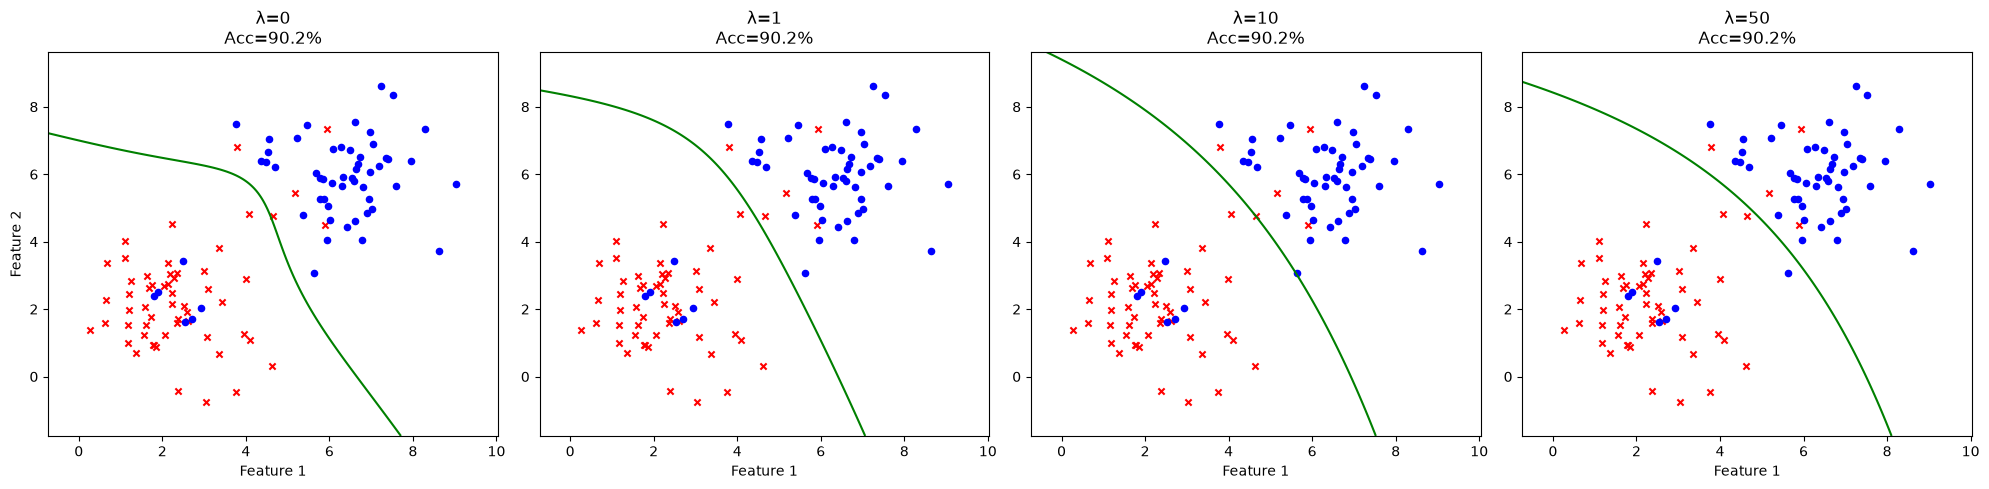

In [36]:
fig, axes = plt.subplots(1, len(lambdas_to_try), figsize=(20, 5))

x1_range = np.linspace(X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1, 200)
x2_range = np.linspace(X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1, 200)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid_points = np.column_stack([xx1.ravel(), xx2.ravel()])
grid_poly = map_polynomial_features(grid_points, degree=degree)
grid_poly_norm = (grid_poly - mu_poly_noisy) / sigma_poly_noisy

for ax, lam in zip(axes, lambdas_to_try):
    w_reg = results[lam]["w"]
    b_reg = results[lam]["b"]
    acc_reg = results[lam]["accuracy"]

    probs = predict_proba(grid_poly_norm, w_reg, b_reg).reshape(xx1.shape)

    ax.scatter(X_noisy[y_noisy == 0, 0], X_noisy[y_noisy == 0, 1], c='red', marker='x', s=20)
    ax.scatter(X_noisy[y_noisy == 1, 0], X_noisy[y_noisy == 1, 1], c='blue', marker='o', s=20)
    ax.contour(xx1, xx2, probs, levels=[0.5], colors='green')
    ax.set_title(f"λ={lam}\nAcc={acc_reg:.1f}%")
    ax.set_xlabel('Feature 1')

axes[0].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

## Step 22: Pushing λ Higher to See Full Effect

Our λ values up to 50 only shifted the boundary in sparse regions, not near
the dense, noisy cluster where it actually matters for accuracy. Let's try
much larger λ values to see regularization actually override the data-fit
term and simplify the boundary near the noisy points too — and to see
underfitting kick in when λ gets too extreme.

In [37]:
lambdas_high = [0, 50, 200, 1000]
results_high = {}

for lam in lambdas_high:
    print(f"\n--- Training with lambda = {lam} ---")
    w_reg, b_reg, cost_hist_reg = gradient_descent_regularized(
        X_poly_noisy_norm, y_noisy,
        w_in=np.zeros(X_poly_noisy_norm.shape[1]),
        b_in=0.0,
        alpha=0.5,
        num_iters=3000,
        lambda_=lam
    )
    y_pred_reg = predict_class(X_poly_noisy_norm, w_reg, b_reg)
    acc_reg = np.mean(y_pred_reg == y_noisy) * 100
    print(f"Training accuracy (lambda={lam}): {acc_reg:.2f}%")
    print(f"Sum of |w|: {np.sum(np.abs(w_reg)):.4f}")  # watch weights shrink

    results_high[lam] = {"w": w_reg, "b": b_reg, "accuracy": acc_reg}


--- Training with lambda = 0 ---
Iteration    0: Cost = 0.3420
Iteration  100: Cost = 0.2899
Iteration  200: Cost = 0.2885
Iteration  300: Cost = 0.2875
Iteration  400: Cost = 0.2867
Iteration  500: Cost = 0.2860
Iteration  600: Cost = 0.2854
Iteration  700: Cost = 0.2849
Iteration  800: Cost = 0.2845
Iteration  900: Cost = 0.2840
Iteration 1000: Cost = 0.2837
Iteration 1100: Cost = 0.2833
Iteration 1200: Cost = 0.2829
Iteration 1300: Cost = 0.2826
Iteration 1400: Cost = 0.2823
Iteration 1500: Cost = 0.2820
Iteration 1600: Cost = 0.2817
Iteration 1700: Cost = 0.2814
Iteration 1800: Cost = 0.2811
Iteration 1900: Cost = 0.2809
Iteration 2000: Cost = 0.2806
Iteration 2100: Cost = 0.2804
Iteration 2200: Cost = 0.2801
Iteration 2300: Cost = 0.2799
Iteration 2400: Cost = 0.2796
Iteration 2500: Cost = 0.2794
Iteration 2600: Cost = 0.2792
Iteration 2700: Cost = 0.2789
Iteration 2800: Cost = 0.2787
Iteration 2900: Cost = 0.2785
Iteration 2999: Cost = 0.2783
Training accuracy (lambda=0): 90.18%

/var/folders/8t/519wlnnn3y7bzvc4w12fjlsh0000gn/T/ipykernel_17989/1402627368.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/var/folders/8t/519wlnnn3y7bzvc4w12fjlsh0000gn/T/ipykernel_17989/706990152.py:21: RuntimeWarning: overflow encountered in square
  reg_term = (lambda_ / (2 * m)) * np.sum(w ** 2)
/var/folders/8t/519wlnnn3y7bzvc4w12fjlsh0000gn/T/ipykernel_17989/3895007554.py:18: RuntimeWarning: overflow encountered in multiply
  dj_dw = dj_dw + (lambda_ / m) * w


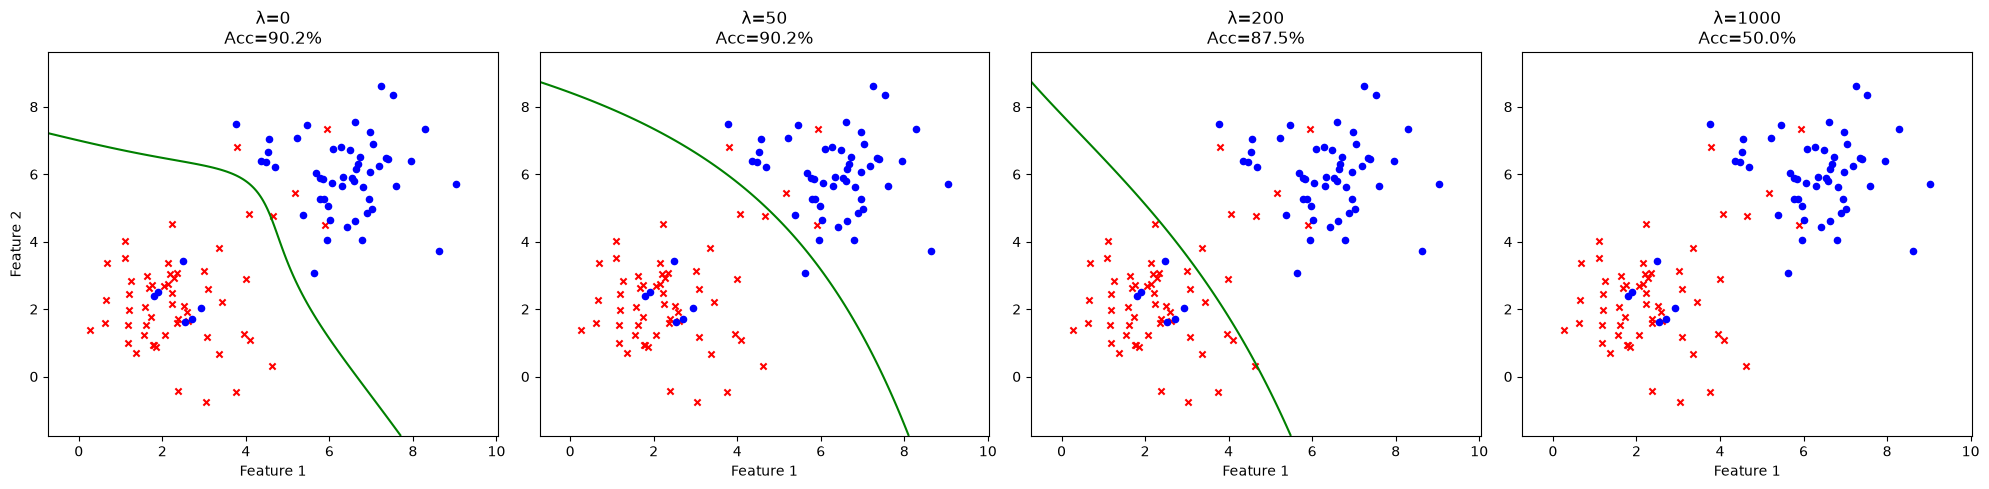

In [38]:
fig, axes = plt.subplots(1, len(lambdas_high), figsize=(20, 5))

for ax, lam in zip(axes, lambdas_high):
    w_reg = results_high[lam]["w"]
    b_reg = results_high[lam]["b"]
    acc_reg = results_high[lam]["accuracy"]

    probs = predict_proba(grid_poly_norm, w_reg, b_reg).reshape(xx1.shape)

    ax.scatter(X_noisy[y_noisy == 0, 0], X_noisy[y_noisy == 0, 1], c='red', marker='x', s=20)
    ax.scatter(X_noisy[y_noisy == 1, 0], X_noisy[y_noisy == 1, 1], c='blue', marker='o', s=20)
    ax.contour(xx1, xx2, probs, levels=[0.5], colors='green')
    ax.set_title(f"λ={lam}\nAcc={acc_reg:.1f}%")
    ax.set_xlabel('Feature 1')

axes[0].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

## Step 23: Summary — The Bias-Variance Tradeoff

Our experiment across λ = [0, 50, 200, 1000] traced out the full
regularization spectrum:

| λ | Accuracy | Boundary Behavior |
|---|----------|-------------------|
| 0 | 90.2% | Bends to chase noisy/mislabeled points (overfitting) |
| 50 | 90.2% | Nearly identical — not yet strong enough to matter |
| 200 | 87.5% | Visibly straightening, trading fit for simplicity |
| 1000 | 50.0% | Collapsed — weights squeezed too close to zero, model can't use the features at all (underfitting) |

This is the **bias-variance tradeoff** in action:
- **Low λ → low bias, high variance** (fits training data closely, including
  its noise — may not generalize)
- **High λ → high bias, low variance** (ignores training data structure
  entirely — too simple to be useful)
- The right λ sits somewhere in between, and in real projects it's typically
  chosen using a **validation set** (a concept from later in the
  specialization) rather than guesswork.

For this project, we don't have a validation set (that's Course 2 material),
so we're demonstrating the *mechanism* of regularization rather than
formally tuning λ — which is the correct scope for Week 3.

## Step 24: Learning Rate Experimentation

Just like in Week 1, let's see what happens with a poorly chosen learning
rate — this time on the plain (non-regularized, non-polynomial) logistic
regression model, since that's the cleanest place to see the effect clearly.

- **Too small** (e.g. 0.001): cost decreases, but painfully slowly
- **Good** (e.g. 0.1, what we used originally): smooth, fast convergence
- **Too large** (e.g. 5 or 10): cost may oscillate or diverge (increase)
  instead of decreasing

In [39]:
learning_rates = [0.001, 0.1, 5]
lr_results = {}

for lr in learning_rates:
    print(f"\n--- Learning rate = {lr} ---")
    w_lr, b_lr, cost_hist_lr = gradient_descent(
        X, y,
        w_in=np.zeros(X.shape[1]),
        b_in=0.0,
        alpha=lr,
        num_iters=1000
    )
    lr_results[lr] = cost_hist_lr


--- Learning rate = 0.001 ---
Iteration    0: Cost = 0.6910
Iteration  100: Cost = 0.6040
Iteration  200: Cost = 0.5887
Iteration  300: Cost = 0.5829
Iteration  400: Cost = 0.5787
Iteration  500: Cost = 0.5749
Iteration  600: Cost = 0.5712
Iteration  700: Cost = 0.5675
Iteration  800: Cost = 0.5638
Iteration  900: Cost = 0.5602
Iteration  999: Cost = 0.5567

--- Learning rate = 0.1 ---
Iteration    0: Cost = 0.5901
Iteration  100: Cost = 0.3399
Iteration  200: Cost = 0.2337
Iteration  300: Cost = 0.1786
Iteration  400: Cost = 0.1454
Iteration  500: Cost = 0.1233
Iteration  600: Cost = 0.1075
Iteration  700: Cost = 0.0956
Iteration  800: Cost = 0.0864
Iteration  900: Cost = 0.0790
Iteration  999: Cost = 0.0729

--- Learning rate = 5 ---
Iteration    0: Cost = 10.6298
Iteration  100: Cost = 0.0016
Iteration  200: Cost = 0.0013
Iteration  300: Cost = 0.0012
Iteration  400: Cost = 0.0012
Iteration  500: Cost = 0.0012
Iteration  600: Cost = 0.0012
Iteration  700: Cost = 0.0012
Iteration  8

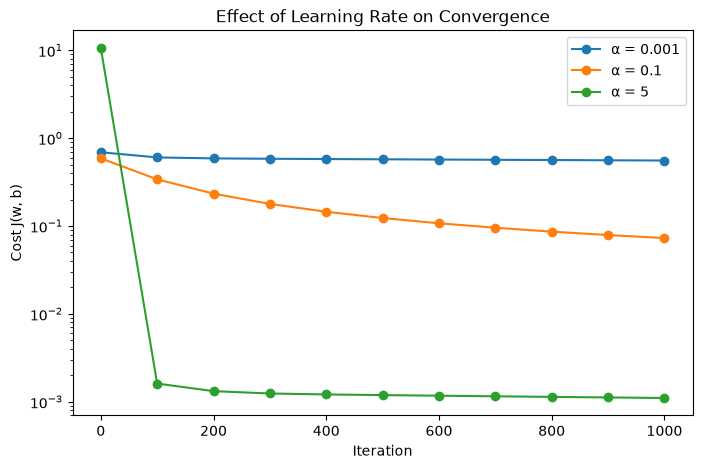

In [40]:
plt.figure(figsize=(8, 5))
for lr, cost_hist in lr_results.items():
    iterations = range(0, len(cost_hist) * 100, 100)
    plt.plot(iterations, cost_hist, marker='o', label=f'α = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.yscale('log')  # log scale helps show divergence clearly if it happens
plt.show()

## Step 25: Learning Rate — Observations

- **α = 0.001**: Cost barely decreases over 1000 iterations — clearly too
  small, wasting computation without making meaningful progress.
- **α = 0.1**: Smooth, steady convergence — our chosen default, a good
  balance of speed and stability.
- **α = 5**: Converges even faster than α=0.1, reaching the lowest cost of
  the three with no oscillation or divergence.

**Why didn't α=5 diverge, as "too-large" learning rates typically do?**
Divergence happens when a step size overshoots the minimum so far that the
next gradient points the model even further away, causing cost to bounce up
instead of down. Whether this happens depends on the curvature of the cost
surface — which depends on the specific dataset, particularly the scale of
the features. Since our two features here are on a similar, modest scale
(0–10) and the classes are fairly well-separated, the cost surface is smooth
enough that even a large step size still lands closer to the minimum rather
than overshooting past it.

**Takeaway:** there's no single "safe" learning rate that works for every
dataset — it depends on feature scale and the shape of the cost function.
This is exactly why we normalized features before training on polynomial
features earlier (Step 14) — without that step, a similarly large learning
rate would likely have diverged instead.